In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import scipy.stats as stats

In [3]:
df = pd.read_csv("/content/employee_performance.csv")

In [4]:
df

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,EMP00001,HR,28,81624,24,47,90.4,Yes
1,EMP00002,Finance,29,92648,22,64,100.0,Yes
2,EMP00003,HR,48,104764,1,35,41.8,No
3,EMP00004,HR,53,121456,18,42,82.6,Yes
4,EMP00005,Engineering,35,122212,19,47,79.4,Yes
...,...,...,...,...,...,...,...,...
4995,EMP04996,Engineering,23,126330,9,40,52.2,No
4996,EMP04997,Operations,46,107510,5,41,52.6,No
4997,EMP04998,Customer Support,33,78501,20,43,93.8,Yes
4998,EMP04999,HR,56,108571,13,40,59.4,No


In [5]:
print(df.head())

  Employee_ID   Department  Age  Salary  Projects_Completed  Working_Hours  \
0    EMP00001           HR   28   81624                  24             47   
1    EMP00002      Finance   29   92648                  22             64   
2    EMP00003           HR   48  104764                   1             35   
3    EMP00004           HR   53  121456                  18             42   
4    EMP00005  Engineering   35  122212                  19             47   

   Performance_Score Promotion_Status  
0               90.4              Yes  
1              100.0              Yes  
2               41.8               No  
3               82.6              Yes  
4               79.4              Yes  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         5000 non-null   object 
 1   Department          5000 non-null   object 
 2   Age                 5000 non-null   int64  
 3   Salary              5000 non-null   int64  
 4   Projects_Completed  5000 non-null   int64  
 5   Working_Hours       5000 non-null   int64  
 6   Performance_Score   5000 non-null   float64
 7   Promotion_Status    5000 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 312.6+ KB
None


In [7]:
print(df.isnull().sum())

Employee_ID           0
Department            0
Age                   0
Salary                0
Projects_Completed    0
Working_Hours         0
Performance_Score     0
Promotion_Status      0
dtype: int64


In [8]:
mean_salary = df['Salary'].mean()
print("Mean Salary:", mean_salary)

Mean Salary: 109534.9714


In [9]:
median_salary = df['Salary'].median()
print("Median Salary:", median_salary)

Median Salary: 108759.0


In [10]:
mode_salary = df['Salary'].mode()[0]
print("Mode Salary:", mode_salary)

Mode Salary: 95908


In [11]:
variance_projects = df['Projects_Completed'].var()
print("Variance:", variance_projects)

Variance: 53.08881280256004


In [12]:
std_projects = df['Projects_Completed'].std()
print("Standard Deviation:", std_projects)

Standard Deviation: 7.286207024409891


In [13]:
promotion_probability = (
    df['Promotion_Status'] == 'Yes'
).mean()

print("Probability of Promotion:")
print(promotion_probability)

Probability of Promotion:
0.4732


In [14]:
contingency_table = pd.crosstab(
    df['Department'],
    df['Promotion_Status']
)

print(contingency_table)

Promotion_Status   No  Yes
Department                
Admin             276  272
Customer Support  311  268
Engineering       305  260
Finance           310  251
HR                309  281
IT                298  278
Marketing         287  263
Operations        259  243
Sales             279  250


In [15]:
high_perf = df[
    df['Performance_Score'] > 80
]

conditional_probability = (
    high_perf['Promotion_Status'] == 'Yes'
).mean()

print("Conditional Probability:")
print(conditional_probability)

Conditional Probability:
0.9968186638388123


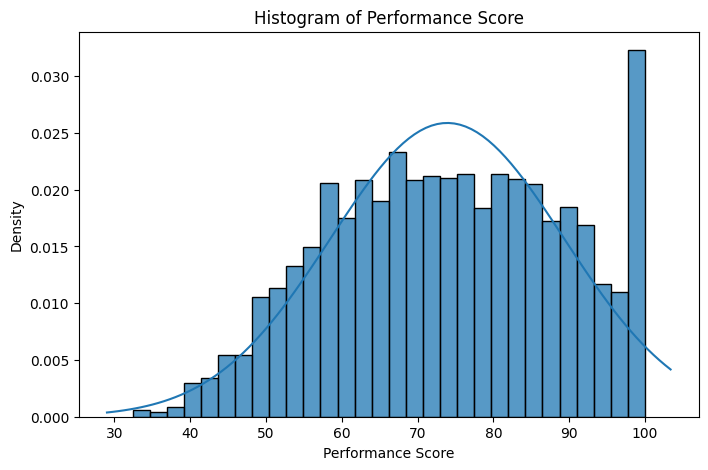

In [16]:
scores = df['Performance_Score']

plt.figure(figsize=(8,5))

sns.histplot(
    scores,
    bins=30,
    stat='density'
)

mu, sigma = norm.fit(scores)

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mu, sigma)

plt.plot(x, p)

plt.title("Histogram of Performance Score")

plt.xlabel("Performance Score")
plt.ylabel("Density")

plt.show()

In [17]:
salary_skewness = df['Salary'].skew()

print("Skewness:", salary_skewness)

Skewness: 0.29601361031939877


In [18]:
salary_kurtosis = df['Salary'].kurt()

print("Kurtosis:", salary_kurtosis)

Kurtosis: -0.2964075865464708


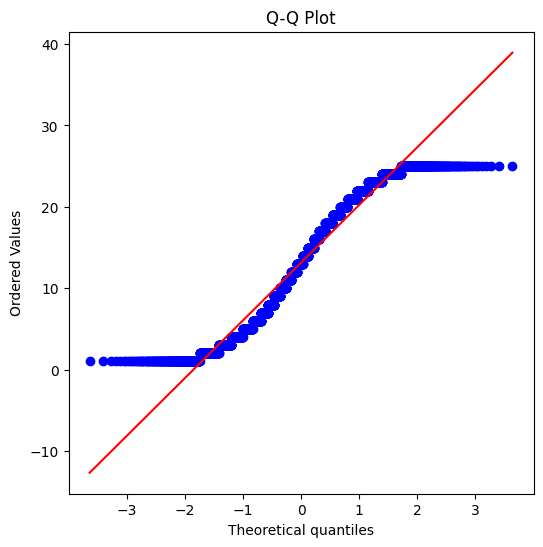

In [19]:
plt.figure(figsize=(6,6))

stats.probplot(
    df['Projects_Completed'],
    dist='norm',
    plot=plt
)

plt.title("Q-Q Plot")

plt.show()

In [20]:
vectors = df[
    ['Projects_Completed', 'Working_Hours']
].head()

print(vectors)

   Projects_Completed  Working_Hours
0                  24             47
1                  22             64
2                   1             35
3                  18             42
4                  19             47


In [21]:
v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

dot_product = np.dot(v1, v2)

print("Dot Product:", dot_product)

Dot Product: 3536


In [22]:
norm1 = np.linalg.norm(v1, 1)

print("Norm 1:", norm1)

Norm 1: 71.0


In [23]:
norm2 = np.linalg.norm(v1, 2)

print("Norm 2:", norm2)

Norm 2: 52.773099207835045


In [24]:
cos_theta = np.dot(v1, v2) / (
    np.linalg.norm(v1) *
    np.linalg.norm(v2)
)

angle = np.arccos(cos_theta)

print("Angle:", angle)

Angle: 0.14102590569964474


In [25]:
print("1. High performance employees are more likely to get promoted.")

print("2. More completed projects improve performance.")

print("3. Salary distribution is slightly skewed.")

print("4. Working hours positively affect performance.")

print("5. Engineering and IT departments have higher salaries.")

1. High performance employees are more likely to get promoted.
2. More completed projects improve performance.
3. Salary distribution is slightly skewed.
4. Working hours positively affect performance.
5. Engineering and IT departments have higher salaries.
